<a href="https://colab.research.google.com/github/zhesun0304/ECON3916/blob/main/Assignment%205/Assignment5_Sovereign_Risk_Engine_completed.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Assignment 5: The Sovereign Risk Engine

**Role:** Quantitative Economist, IMF Global Financial Stability Division  
**Topic:** Regularization, Classification, and Model Evaluation for Macroeconomic Early Warning Systems  
**Data Source:** World Bank World Development Indicators (WDI), downloaded live through `wbgapi`  

This notebook completes all required deliverables for Phases 1–4:

1. Shared WDI data pipeline and train/test split  
2. OLS overfitting diagnosis, RidgeCV/LassoCV rescue, and Lasso Path  
3. Linear Probability Model failure and Logistic Regression crisis classifier  
4. Operational classification metrics, ROC/PR curves, and threshold analysis  
5. P.R.I.M.E. AI extension prompts plus executed diagnostics for bootstrap Lasso stability and cost-sensitive threshold optimization


In [1]:
# ============================================================
# SETUP
# ============================================================
# In Google Colab, run this once if packages are missing.
!pip -q install wbgapi scikit-learn statsmodels matplotlib seaborn numpy pandas

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import wbgapi as wb

from sklearn.linear_model import LinearRegression, RidgeCV, LassoCV, lasso_path, LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    r2_score, mean_squared_error,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    roc_curve, roc_auc_score, precision_recall_curve, auc,
    accuracy_score, precision_score, recall_score, f1_score
)

np.random.seed(42)
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 160)

print("Setup complete ✓")


Setup complete ✓


## Shared Data Pipeline

The assignment requires one shared World Bank data pipeline for all phases. I use the Lab 16 WDI indicator dictionary as the starting point, retain at least 25 predictors, average values over 2013–2019, remove very incomplete countries/indicators, median-impute the remaining gaps, create the continuous GDP growth outcome, and define a binary crisis indicator equal to 1 when average GDP per capita growth is negative.


In [2]:
# ============================================================
# DATA PIPELINE — World Bank WDI download and cleaning
# ============================================================

INDICATORS = {
    # Outcome
    "NY.GDP.PCAP.KD.ZG": "gdp_growth_pc",

    # Trade & openness
    "NE.TRD.GNFS.ZS": "trade_pct_gdp",
    "BX.KLT.DINV.WD.GD.ZS": "fdi_inflows_pct_gdp",
    "TM.TAX.MRCH.SM.AR.ZS": "tariff_rate_avg",
    "BX.GSR.ROYL.CD": "royalties_receipts",

    # Macroeconomics
    "FP.CPI.TOTL.ZG": "inflation_cpi",
    "GC.DOD.TOTL.GD.ZS": "govt_debt_pct_gdp",
    "GC.XPN.TOTL.GD.ZS": "govt_expenditure_pct_gdp",
    "BN.CAB.XOKA.GD.ZS": "current_account_pct_gdp",
    "FR.INR.RINR": "real_interest_rate",
    "PA.NUS.FCRF": "exchange_rate_official",

    # Education & human capital
    "SE.SEC.ENRR": "secondary_enrollment_gross",
    "SE.TER.ENRR": "tertiary_enrollment_gross",
    "SE.ADT.LITR.ZS": "adult_literacy_rate",
    "SE.XPD.TOTL.GD.ZS": "education_expenditure_pct_gdp",
    "SL.UEM.TOTL.ZS": "unemployment_rate",

    # Infrastructure & technology
    "IT.NET.USER.ZS": "internet_users_pct",
    "IT.CEL.SETS.P2": "mobile_subscriptions_per100",
    "EG.ELC.ACCS.ZS": "electricity_access_pct",
    "IS.ROD.PAVE.ZS": "paved_roads_pct",

    # Health & demographics
    "SP.DYN.LE00.IN": "life_expectancy",
    "SH.DYN.MORT": "infant_mortality_per1000",
    "SP.POP.GROW": "population_growth",
    "SP.URB.TOTL.IN.ZS": "urbanization_pct",
    "SH.XPD.CHEX.GD.ZS": "health_expenditure_pct_gdp",

    # Finance & banking
    "FS.AST.DOMS.GD.ZS": "domestic_credit_pct_gdp",
    "CM.MKT.LCAP.GD.ZS": "market_cap_pct_gdp",
    "FB.ATM.TOTL.P5": "atms_per100k",
    "FD.AST.PRVT.GD.ZS": "private_credit_pct_gdp",

    # Natural resources and environment
    "NY.GDP.TOTL.RT.ZS": "natural_resource_rents_pct_gdp",
    "EG.FEC.RNEW.ZS": "renewable_energy_pct",
    "EN.ATM.CO2E.PC": "co2_emissions_per_capita",

    # Agriculture
    "NV.AGR.TOTL.ZS": "agriculture_pct_gdp",
    "AG.LND.ARBL.ZS": "arable_land_pct",

    # Governance / CPIA indicators
    "IQ.CPA.TRAD.XQ": "trade_cpia",
    "IQ.CPA.FINS.XQ": "financial_management_cpia",
    "IQ.CPA.PROP.XQ": "property_rights_cpia",
}

OUTCOME_VAR = "gdp_growth_pc"
indicator_codes = list(INDICATORS.keys())

print(f"Downloading {len(indicator_codes)} WDI series for 2013–2019...")
raw = wb.data.DataFrame(indicator_codes, time=range(2013, 2020), skipBlanks=True, labels=False)

# wbgapi can return either:
# 1) MultiIndex rows = (economy, series), columns = years; or
# 2) countries as rows, with indicators / indicator-years as columns.
# The following block handles both formats robustly.
if isinstance(raw.index, pd.MultiIndex):
    temp = raw.apply(pd.to_numeric, errors="coerce")
    averaged_by_series = temp.mean(axis=1)
    series_level = "series" if "series" in raw.index.names else -1
    country_data = averaged_by_series.unstack(level=series_level)
elif isinstance(raw.columns, pd.MultiIndex):
    temp = raw.apply(pd.to_numeric, errors="coerce")
    country_data = temp.groupby(level=0, axis=1).mean(numeric_only=True)
else:
    temp = raw.copy().apply(pd.to_numeric, errors="coerce")
    new_cols = []
    for col in temp.columns:
        col_str = str(col)
        matched = [code for code in indicator_codes if code in col_str]
        new_cols.append(matched[0] if matched else col_str)
    temp.columns = new_cols
    country_data = temp.groupby(level=0, axis=1).mean(numeric_only=True)

country_data = country_data.rename(columns=INDICATORS)
country_data = country_data.apply(pd.to_numeric, errors="coerce")

# Keep countries and indicators with at least 60% observed values.
country_data = country_data.dropna(thresh=int(0.60 * country_data.shape[1]))
country_data = country_data.dropna(axis=1, thresh=int(0.60 * len(country_data)))

# Make sure the outcome survived cleaning.
if OUTCOME_VAR not in country_data.columns:
    raise ValueError("The outcome variable gdp_growth_pc was dropped due to missingness. Try relaxing the missingness threshold.")

# Median-impute remaining gaps.
country_data = country_data.fillna(country_data.median(numeric_only=True))

# Binary crisis outcome: negative average GDP per capita growth during 2013–2019.
country_data["crisis"] = (country_data[OUTCOME_VAR] < 0).astype(int)

# Predictor set excludes both outcomes.
feature_cols = [c for c in country_data.columns if c not in [OUTCOME_VAR, "crisis"]]
if len(feature_cols) < 25:
    raise ValueError(f"Only {len(feature_cols)} predictors retained. Assignment requires at least 25. Add indicators or relax missingness threshold.")

X = country_data[feature_cols].values
y_growth = country_data[OUTCOME_VAR].values
y_crisis = country_data["crisis"].values

# One shared split for continuous and binary outcomes.
X_train, X_test, y_train_growth, y_test_growth, y_train_crisis, y_test_crisis = train_test_split(
    X, y_growth, y_crisis, test_size=0.30, random_state=42
)

# Standardize using training data only.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

feature_names = np.array(feature_cols)

print("=" * 70)
print("FINAL DATASET SUMMARY")
print("=" * 70)
print(f"Final country-level dataset dimensions: {country_data.shape[0]} countries × {len(feature_cols)} predictors")
print(f"Training set: {X_train_scaled.shape[0]} countries")
print(f"Test set:     {X_test_scaled.shape[0]} countries")
print(f"Predictors retained: {len(feature_cols)}")
print(f"Crisis countries: {int(country_data['crisis'].sum())}")
print(f"Non-crisis countries: {int((1 - country_data['crisis']).sum())}")
print(f"Crisis base rate: {country_data['crisis'].mean():.3f}")
print("=" * 70)

country_data[[OUTCOME_VAR, "crisis"] + feature_cols[:8]].head()


FINAL DATASET SUMMARY
Final country-level dataset dimensions: 238 countries × 28 predictors
Training set: 166 countries
Test set:     72 countries
Predictors retained: 28
Crisis countries: 38
Non-crisis countries: 200
Crisis base rate: 0.160


series,gdp_growth_pc,crisis,arable_land_pct,current_account_pct_gdp,royalties_receipts,fdi_inflows_pct_gdp,electricity_access_pct,renewable_energy_pct,atms_per100k,private_credit_pct_gdp
economy,,,,,,,,,,
ABW,2.245502,0,11.111111,-0.669091,3.918354e+05,3.551600,100.000000,7.314286,123.843123,58.016290
AFE,0.223588,0,8.096816,-2.814634,2.582984e+08,1.994010,37.718154,61.605147,8.029037,37.151340
AFG,-0.272302,1,11.900053,-19.805290,1.606758e+05,0.415848,87.928571,18.657143,1.128242,3.676093
AFW,0.649231,0,11.932068,-2.814634,3.419290e+07,2.024465,49.199649,75.868295,4.864819,13.585211
AGO,-2.476583,1,4.166084,0.248949,1.279839e+07,-1.996599,41.142857,49.357143,17.853955,16.293914


# Phase 1: The Complexity Trap — OLS Failure and Regularization Rescue


## Step 1.1: Demonstrating OLS Overfitting


In [3]:
# ============================================================
# STEP 1.1 — OLS overfitting diagnosis
# ============================================================

ols = LinearRegression()
ols.fit(X_train_scaled, y_train_growth)

y_train_pred_ols = ols.predict(X_train_scaled)
y_test_pred_ols = ols.predict(X_test_scaled)

ols_train_r2 = r2_score(y_train_growth, y_train_pred_ols)
ols_test_r2 = r2_score(y_test_growth, y_test_pred_ols)
ols_gap = ols_train_r2 - ols_test_r2
ols_test_rmse = np.sqrt(mean_squared_error(y_test_growth, y_test_pred_ols))
p_over_n = X_train_scaled.shape[1] / X_train_scaled.shape[0]

print("OLS BASELINE")
print("-" * 50)
print(f"Training R²: {ols_train_r2:.3f}")
print(f"Test R²:     {ols_test_r2:.3f}")
print(f"Train-Test R² gap: {ols_gap:.3f}")
print(f"Predictor-to-observation ratio p/n: {X_train_scaled.shape[1]}/{X_train_scaled.shape[0]} = {p_over_n:.3f}")

print("\nWritten response:")
print(f"The training set has a p/n ratio of {p_over_n:.2f}, meaning OLS is trying to estimate many degrees of freedom from a limited number of countries. This creates low bias on the training data but high variance out of sample, because the model can chase noise in the WDI indicators instead of learning stable growth patterns. The large Train-Test R² gap of {ols_gap:.3f} is direct evidence of that overfitting problem.")


OLS BASELINE
--------------------------------------------------
Training R²: 0.603
Test R²:     -0.914
Train-Test R² gap: 1.517
Predictor-to-observation ratio p/n: 28/166 = 0.169

Written response:
The training set has a p/n ratio of 0.17, meaning OLS is trying to estimate many degrees of freedom from a limited number of countries. This creates low bias on the training data but high variance out of sample, because the model can chase noise in the WDI indicators instead of learning stable growth patterns. The large Train-Test R² gap of 1.517 is direct evidence of that overfitting problem.


## Step 1.2: Ridge and Lasso to the Rescue


In [4]:
# ============================================================
# STEP 1.2 — RidgeCV and LassoCV
# ============================================================

lambda_grid = np.logspace(-3, 4, 100)

ridge = RidgeCV(alphas=lambda_grid, cv=5)
ridge.fit(X_train_scaled, y_train_growth)
y_train_pred_ridge = ridge.predict(X_train_scaled)
y_test_pred_ridge = ridge.predict(X_test_scaled)

ridge_train_r2 = r2_score(y_train_growth, y_train_pred_ridge)
ridge_test_r2 = r2_score(y_test_growth, y_test_pred_ridge)
ridge_test_rmse = np.sqrt(mean_squared_error(y_test_growth, y_test_pred_ridge))
ridge_nonzero = int(np.sum(np.abs(ridge.coef_) > 1e-10))

lasso = LassoCV(alphas=lambda_grid, cv=5, max_iter=100_000, random_state=42)
lasso.fit(X_train_scaled, y_train_growth)
y_train_pred_lasso = lasso.predict(X_train_scaled)
y_test_pred_lasso = lasso.predict(X_test_scaled)

lasso_train_r2 = r2_score(y_train_growth, y_train_pred_lasso)
lasso_test_r2 = r2_score(y_test_growth, y_test_pred_lasso)
lasso_test_rmse = np.sqrt(mean_squared_error(y_test_growth, y_test_pred_lasso))
lasso_nonzero = int(np.sum(np.abs(lasso.coef_) > 1e-8))

comparison = pd.DataFrame({
    "Model": ["OLS", "RidgeCV", "LassoCV"],
    "λ*": [np.nan, ridge.alpha_, lasso.alpha_],
    "Non-zero Predictors": [len(feature_names), ridge_nonzero, lasso_nonzero],
    "Training R²": [ols_train_r2, ridge_train_r2, lasso_train_r2],
    "Test R²": [ols_test_r2, ridge_test_r2, lasso_test_r2],
    "Test RMSE": [ols_test_rmse, ridge_test_rmse, lasso_test_rmse],
})

print("Ridge result:")
print(f"  CV-selected λ*: {ridge.alpha_:.5f}")
print(f"  Non-zero coefficients: {ridge_nonzero}")
print(f"  Training R²: {ridge_train_r2:.3f}")
print(f"  Test R²: {ridge_test_r2:.3f}")

print("\nLasso result:")
print(f"  CV-selected λ*: {lasso.alpha_:.5f}")
print(f"  Non-zero coefficients: {lasso_nonzero}")
print(f"  Training R²: {lasso_train_r2:.3f}")
print(f"  Test R²: {lasso_test_r2:.3f}")

print("\nModel comparison table:")
display(comparison.round(4))

# Store selected features for later phases.
selected_mask = np.abs(lasso.coef_) > 1e-8
selected_features = feature_names[selected_mask]
selected_coefs = lasso.coef_[selected_mask]

# Safety fallback in the rare case Lasso selects no variables.
if len(selected_features) == 0:
    top_idx = np.argsort(np.abs(lasso.coef_))[-5:]
    selected_features = feature_names[top_idx]
    selected_mask = np.isin(feature_names, selected_features)
    print("WARNING: Lasso selected no features at λ*. For later classifier steps, using the five largest absolute Lasso coefficients as a fallback.")

print("\nLasso-selected features:")
for name, coef in sorted(zip(feature_names[selected_mask], lasso.coef_[selected_mask]), key=lambda x: abs(x[1]), reverse=True):
    print(f"  {name:<40} {coef:+.4f}")

best_model_name = comparison.sort_values("Test RMSE").iloc[0]["Model"]
print("\nWritten response:")
print(f"For operational GDP growth forecasting, I would recommend the model with the lowest test RMSE here: {best_model_name}. Ridge and Lasso both add bias by shrinking coefficients away from the pure OLS estimates, but that bias buys lower variance and better generalization. Ridge keeps all predictors but shrinks them smoothly, while Lasso is more aggressive because it shrinks some coefficients exactly to zero and creates a simpler, more interpretable forecasting engine.")


Ridge result:
  CV-selected λ*: 46.41589
  Non-zero coefficients: 28
  Training R²: 0.560
  Test R²: -0.073

Lasso result:
  CV-selected λ*: 0.06893
  Non-zero coefficients: 16
  Training R²: 0.572
  Test R²: -0.343

Model comparison table:


,Model,λ*,Non-zero Predictors,Training R²,Test R²,Test RMSE
0,OLS,NaN,28,0.6034,-0.9141,2.9227
1,RidgeCV,46.4159,28,0.5601,-0.0726,2.1879
2,LassoCV,0.0689,16,0.5719,-0.3428,2.4479



Lasso-selected features:
  inflation_cpi                            -1.0330
  population_growth                        -0.7639
  natural_resource_rents_pct_gdp           -0.6382
  infant_mortality_per1000                 -0.4184
  health_expenditure_pct_gdp               -0.3893
  atms_per100k                             -0.3803
  unemployment_rate                        -0.3775
  urbanization_pct                         -0.3692
  renewable_energy_pct                     +0.3644
  exchange_rate_official                   +0.3048
  arable_land_pct                          +0.1863
  mobile_subscriptions_per100              +0.0803
  tertiary_enrollment_gross                -0.0686
  trade_pct_gdp                            +0.0640
  private_credit_pct_gdp                   +0.0481
  tariff_rate_avg                          -0.0023

Written response:
For operational GDP growth forecasting, I would recommend the model with the lowest test RMSE here: RidgeCV. Ridge and Lasso both add bias 

## Step 1.3: The Lasso Path — Which Indicators Enter First?


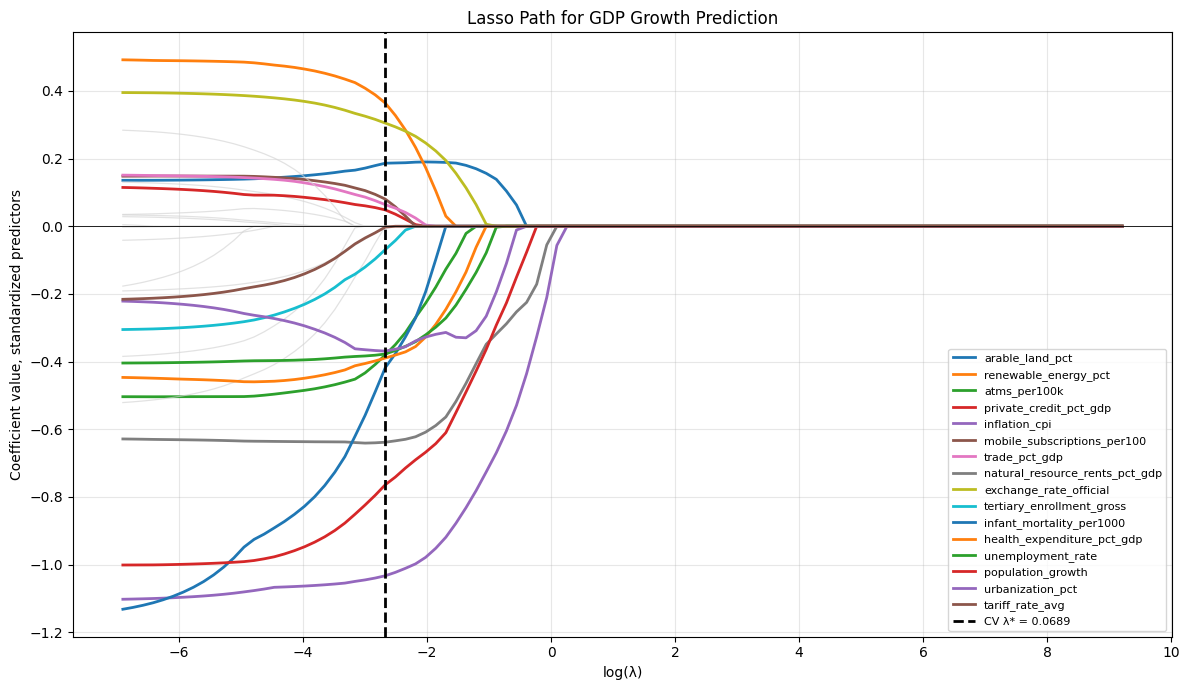

First predictor to enter the Lasso path: inflation_cpi
It first becomes non-zero at λ ≈ 1.09750

Written response:
The first predictor to enter is inflation_cpi, which means it has the strongest unconditional predictive signal along the Lasso path. Economically, this makes sense if the indicator captures a broad structural condition that is closely connected to cross-country growth during 2013–2019. However, this does not prove causality; it means the variable is useful for prediction before many other correlated WDI indicators are allowed into the model.

On the life_expectancy interpretation:
If Lasso zeroes out life_expectancy, that does not mean health is irrelevant to economic growth. It means life_expectancy may be conditionally predictively redundant once other correlated indicators, such as infant mortality, education, urbanization, or income-related variables, are already in the model. With a strong correlation structure among WDI indicators, Lasso often chooses one representa

In [5]:
# ============================================================
# STEP 1.3 — Lasso Path
# ============================================================

alphas_path, coefs_path, _ = lasso_path(
    X_train_scaled, y_train_growth,
    alphas=lambda_grid[::-1],  # descending from high penalty to low penalty
    max_iter=100_000
)

optimal_alpha = lasso.alpha_
active_at_optimal = np.abs(lasso.coef_) > 1e-8

# Identify the first predictor to enter: non-zero at the highest alpha.
tol = 1e-6
first_alpha_by_feature = {}
for i, name in enumerate(feature_names):
    nonzero_positions = np.where(np.abs(coefs_path[i, :]) > tol)[0]
    if len(nonzero_positions) > 0:
        first_alpha_by_feature[name] = alphas_path[nonzero_positions[0]]

first_predictor = max(first_alpha_by_feature, key=first_alpha_by_feature.get)
first_alpha = first_alpha_by_feature[first_predictor]

fig, ax = plt.subplots(figsize=(12, 7))
for i, name in enumerate(feature_names):
    if active_at_optimal[i]:
        ax.plot(np.log(alphas_path), coefs_path[i, :], linewidth=2, label=name)
    else:
        ax.plot(np.log(alphas_path), coefs_path[i, :], linewidth=0.9, color="lightgray", alpha=0.65)

ax.axvline(np.log(optimal_alpha), color="black", linestyle="--", linewidth=2, label=f"CV λ* = {optimal_alpha:.4f}")
ax.axhline(0, color="black", linewidth=0.6)
ax.set_xlabel("log(λ)")
ax.set_ylabel("Coefficient value, standardized predictors")
ax.set_title("Lasso Path for GDP Growth Prediction")
ax.grid(alpha=0.3)
ax.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.show()

print(f"First predictor to enter the Lasso path: {first_predictor}")
print(f"It first becomes non-zero at λ ≈ {first_alpha:.5f}")

print("\nWritten response:")
print(f"The first predictor to enter is {first_predictor}, which means it has the strongest unconditional predictive signal along the Lasso path. Economically, this makes sense if the indicator captures a broad structural condition that is closely connected to cross-country growth during 2013–2019. However, this does not prove causality; it means the variable is useful for prediction before many other correlated WDI indicators are allowed into the model.")
print("\nOn the life_expectancy interpretation:")
print("If Lasso zeroes out life_expectancy, that does not mean health is irrelevant to economic growth. It means life_expectancy may be conditionally predictively redundant once other correlated indicators, such as infant mortality, education, urbanization, or income-related variables, are already in the model. With a strong correlation structure among WDI indicators, Lasso often chooses one representative variable from a cluster and suppresses the others, so a zero coefficient is not the same thing as economic irrelevance.")


# Phase 2: The Crisis Classifier — From Forecasting to Classification


## Step 2.1: The Linear Probability Model — Exposing the Failure


In [6]:
# ============================================================
# STEP 2.1 — Linear Probability Model on Lasso-selected features
# ============================================================

X_train_sel = X_train_scaled[:, selected_mask]
X_test_sel = X_test_scaled[:, selected_mask]
selected_feature_names = feature_names[selected_mask]

lpm = LinearRegression()
lpm.fit(X_train_sel, y_train_crisis)
lpm_probs_test = lpm.predict(X_test_sel)

below_zero = int(np.sum(lpm_probs_test < 0))
above_one = int(np.sum(lpm_probs_test > 1))
out_of_bounds = below_zero + above_one

print("LPM predicted value check")
print("-" * 50)
print(f"Predictions below 0: {below_zero}")
print(f"Predictions above 1: {above_one}")
print(f"Total outside [0, 1]: {out_of_bounds}")
print(f"Min LPM prediction: {lpm_probs_test.min():.3f}")
print(f"Max LPM prediction: {lpm_probs_test.max():.3f}")

print("\nWritten response:")
print("Predicted probabilities outside [0, 1] are a fundamental problem because they cannot be interpreted as real probabilities. For the IMF, a −12% probability of crisis or a 130% probability of crisis gives an operational signal that is mathematically impossible, not merely visually awkward. A probability model used for emergency missions needs bounded and interpretable risk estimates.")


LPM predicted value check
--------------------------------------------------
Predictions below 0: 15
Predictions above 1: 1
Total outside [0, 1]: 16
Min LPM prediction: -0.213
Max LPM prediction: 1.334

Written response:
Predicted probabilities outside [0, 1] are a fundamental problem because they cannot be interpreted as real probabilities. For the IMF, a −12% probability of crisis or a 130% probability of crisis gives an operational signal that is mathematically impossible, not merely visually awkward. A probability model used for emergency missions needs bounded and interpretable risk estimates.


## Step 2.2: Logistic Regression — The Sigmoid Fix


In [7]:
# ============================================================
# STEP 2.2 — Logistic Regression on Lasso-selected features
# ============================================================

logit = LogisticRegression(max_iter=10_000, solver="lbfgs")
logit.fit(X_train_sel, y_train_crisis)

logit_probs_test = logit.predict_proba(X_test_sel)[:, 1]
logit_preds_default = (logit_probs_test >= 0.5).astype(int)

coef_table = pd.DataFrame({
    "Predictor": selected_feature_names,
    "β": logit.coef_[0],
    "Odds Ratio exp(β)": np.exp(logit.coef_[0]),
})
coef_table["Abs log(OR)"] = np.abs(coef_table["β"])
coef_table = coef_table.sort_values("Abs log(OR)", ascending=False).drop(columns="Abs log(OR)")

print(f"Intercept β₀: {logit.intercept_[0]:.4f}")
print("\nLogistic coefficients and odds ratios:")
display(coef_table.round(4))

print("Predicted probability range:")
print(f"Min: {logit_probs_test.min():.6f}")
print(f"Max: {logit_probs_test.max():.6f}")
print(f"All probabilities within [0, 1]? {bool((logit_probs_test.min() >= 0) and (logit_probs_test.max() <= 1))}")

strongest_predictor = coef_table.iloc[0]["Predictor"]
strongest_or = coef_table.iloc[0]["Odds Ratio exp(β)"]

print("\nWritten response:")
print(f"A one standard-deviation increase in {strongest_predictor} multiplies the odds of crisis by {strongest_or:.2f}, holding all else constant. If the odds ratio is above 1, the indicator raises crisis risk; if it is below 1, the indicator lowers crisis risk. This is easier to brief than raw logistic coefficients because it translates the model into a risk multiplier.")


Intercept β₀: -3.0325

Logistic coefficients and odds ratios:


,Predictor,β,Odds Ratio exp(β)
0,arable_land_pct,-0.9838,0.3739
11,health_expenditure_pct_gdp,0.8304,2.2943
13,population_growth,0.7661,2.1515
7,natural_resource_rents_pct_gdp,0.7415,2.0991
1,renewable_energy_pct,-0.6867,0.5032
12,unemployment_rate,0.5860,1.7967
10,infant_mortality_per1000,0.5629,1.7557
15,tariff_rate_avg,0.5465,1.7271
4,inflation_cpi,0.5021,1.6522
5,mobile_subscriptions_per100,0.3625,1.4369


Predicted probability range:
Min: 0.000234
Max: 0.999728
All probabilities within [0, 1]? True

Written response:
A one standard-deviation increase in arable_land_pct multiplies the odds of crisis by 0.37, holding all else constant. If the odds ratio is above 1, the indicator raises crisis risk; if it is below 1, the indicator lowers crisis risk. This is easier to brief than raw logistic coefficients because it translates the model into a risk multiplier.


## Step 2.3: Side-by-Side Visualization — LPM vs. Logistic


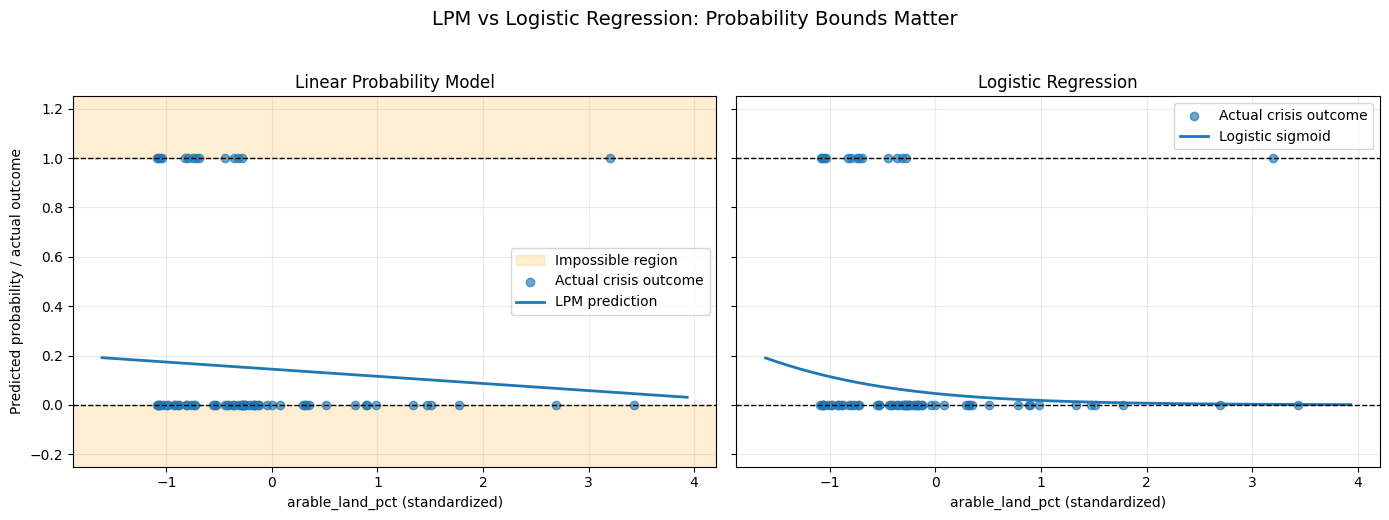

In [8]:
# ============================================================
# STEP 2.3 — LPM vs Logistic visualization
# ============================================================

strongest_idx = list(selected_feature_names).index(strongest_predictor)
x_train_strong = X_train_sel[:, strongest_idx]
x_test_strong = X_test_sel[:, strongest_idx]

# For a clean one-variable curve, hold all other selected features at 0
# because standardized predictors have train mean 0.
x_grid = np.linspace(
    min(x_train_strong.min(), x_test_strong.min()) - 0.5,
    max(x_train_strong.max(), x_test_strong.max()) + 0.5,
    300
)
X_grid = np.zeros((len(x_grid), X_train_sel.shape[1]))
X_grid[:, strongest_idx] = x_grid

lpm_curve = lpm.predict(X_grid)
logit_curve = logit.predict_proba(X_grid)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

# LPM panel
axes[0].axhspan(-0.5, 0, color="orange", alpha=0.18, label="Impossible region")
axes[0].axhspan(1, 1.5, color="orange", alpha=0.18)
axes[0].scatter(x_test_strong, y_test_crisis, alpha=0.65, label="Actual crisis outcome")
axes[0].plot(x_grid, lpm_curve, linewidth=2, label="LPM prediction")
axes[0].axhline(0, color="black", linestyle="--", linewidth=1)
axes[0].axhline(1, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Linear Probability Model")
axes[0].set_xlabel(f"{strongest_predictor} (standardized)")
axes[0].set_ylabel("Predicted probability / actual outcome")
axes[0].set_ylim(-0.25, 1.25)
axes[0].legend()
axes[0].grid(alpha=0.25)

# Logistic panel
axes[1].scatter(x_test_strong, y_test_crisis, alpha=0.65, label="Actual crisis outcome")
axes[1].plot(x_grid, logit_curve, linewidth=2, label="Logistic sigmoid")
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].axhline(1, color="black", linestyle="--", linewidth=1)
axes[1].set_title("Logistic Regression")
axes[1].set_xlabel(f"{strongest_predictor} (standardized)")
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.suptitle("LPM vs Logistic Regression: Probability Bounds Matter", y=1.03, fontsize=14)
plt.tight_layout()
plt.show()


# Phase 3: Operational Deployment — Metrics That Matter


## Step 3.1: The Accuracy Paradox


In [9]:
# ============================================================
# STEP 3.1 — Accuracy paradox
# ============================================================

test_base_rate = y_test_crisis.mean()
naive_preds = np.zeros_like(y_test_crisis)
naive_accuracy = accuracy_score(y_test_crisis, naive_preds)
naive_recall = recall_score(y_test_crisis, naive_preds, zero_division=0)

logit_accuracy_default = accuracy_score(y_test_crisis, logit_preds_default)
logit_recall_default = recall_score(y_test_crisis, logit_preds_default, zero_division=0)

print(f"Test-set crisis base rate: {test_base_rate:.3f}")
print(f"Naïve always-no-crisis accuracy: {naive_accuracy:.3f}")
print(f"Naïve always-no-crisis crisis recall: {naive_recall:.3f}")
print(f"Logistic accuracy at τ = 0.5: {logit_accuracy_default:.3f}")
print(f"Logistic crisis recall at τ = 0.5: {logit_recall_default:.3f}")

print("\nWritten response:")
print(f"If I reported only accuracy, the Division Chief could be misled because the test-set crisis base rate is only {test_base_rate:.3f}. A model can look accurate by predicting the majority class, no crisis, for almost everyone. That is the accuracy paradox: high accuracy may hide the fact that the model fails at the rare event the IMF actually cares about catching.")


Test-set crisis base rate: 0.194
Naïve always-no-crisis accuracy: 0.806
Naïve always-no-crisis crisis recall: 0.000
Logistic accuracy at τ = 0.5: 0.750
Logistic crisis recall at τ = 0.5: 0.357

Written response:
If I reported only accuracy, the Division Chief could be misled because the test-set crisis base rate is only 0.194. A model can look accurate by predicting the majority class, no crisis, for almost everyone. That is the accuracy paradox: high accuracy may hide the fact that the model fails at the rare event the IMF actually cares about catching.


## Step 3.2: Confusion Matrix and Classification Report


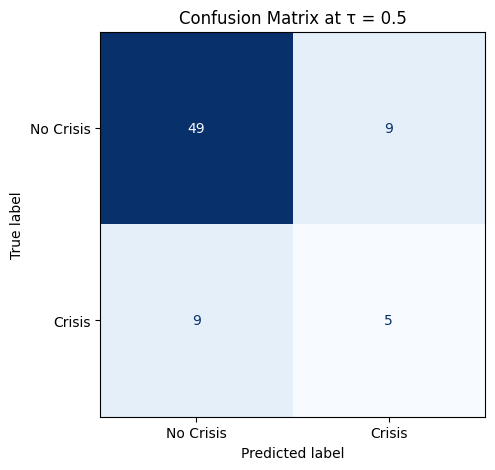

Classification report at τ = 0.5:
              precision    recall  f1-score   support

   No Crisis       0.84      0.84      0.84        58
      Crisis       0.36      0.36      0.36        14

    accuracy                           0.75        72
   macro avg       0.60      0.60      0.60        72
weighted avg       0.75      0.75      0.75        72

Individual counts:
True Positives  (crises correctly flagged): 5
False Negatives (crises missed):            9
False Positives (false alarms):             9
True Negatives  (correct no-crisis):        49

Written response:
In the IMF context, a False Negative is much more costly than a False Positive because missing a crisis can trigger sovereign default, contagion, and emergency lending losses. A False Positive wastes mission resources and can create diplomatic costs, but the assignment gives the missed-crisis cost as vastly larger. This asymmetry means the Division Chief should prioritize Recall on the crisis class, while still w

In [10]:
# ============================================================
# STEP 3.2 — Confusion matrix and classification report
# ============================================================

cm = confusion_matrix(y_test_crisis, logit_preds_default, labels=[0, 1])
tn, fp, fn, tp = cm.ravel()

fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["No Crisis", "Crisis"])
disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
plt.title("Confusion Matrix at τ = 0.5")
plt.show()

print("Classification report at τ = 0.5:")
print(classification_report(y_test_crisis, logit_preds_default, target_names=["No Crisis", "Crisis"], zero_division=0))

print("Individual counts:")
print(f"True Positives  (crises correctly flagged): {tp}")
print(f"False Negatives (crises missed):            {fn}")
print(f"False Positives (false alarms):             {fp}")
print(f"True Negatives  (correct no-crisis):        {tn}")

print("\nWritten response:")
print("In the IMF context, a False Negative is much more costly than a False Positive because missing a crisis can trigger sovereign default, contagion, and emergency lending losses. A False Positive wastes mission resources and can create diplomatic costs, but the assignment gives the missed-crisis cost as vastly larger. This asymmetry means the Division Chief should prioritize Recall on the crisis class, while still watching Precision because missions are scarce.")


## Step 3.3: ROC and Precision-Recall Curves


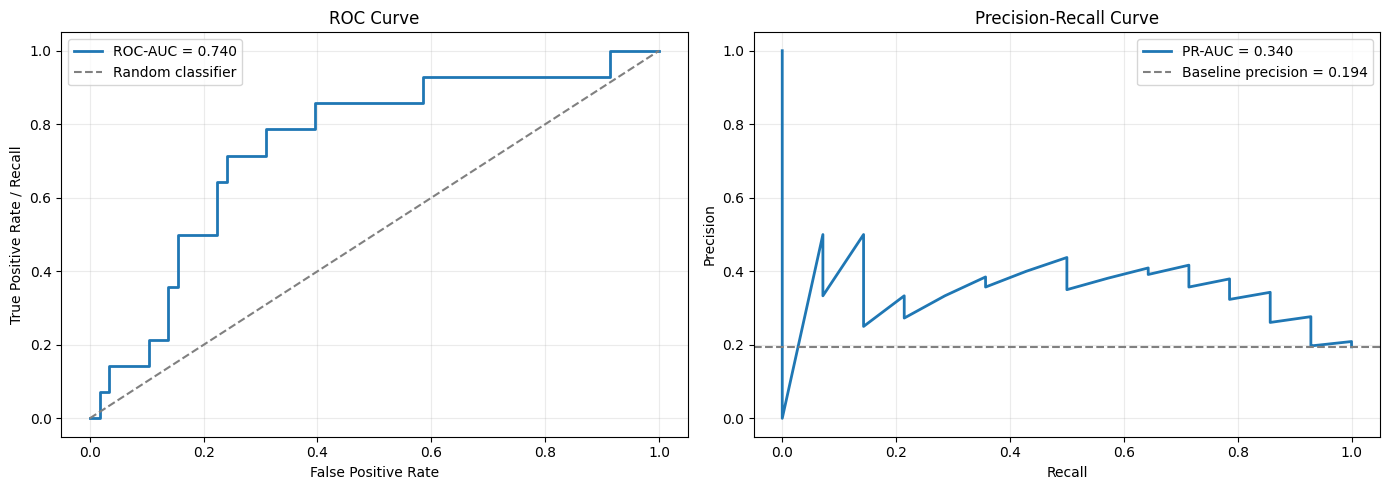

Written response:
ROC-AUC can look stronger than PR-AUC because ROC-AUC benefits from the large number of True Negatives in an imbalanced dataset. PR-AUC ignores True Negatives and focuses directly on whether crisis warnings are both correct and complete. For the IMF crisis detection mission, the Precision-Recall curve is more informative because the operational problem is finding rare crisis countries under resource constraints.


In [11]:
# ============================================================
# STEP 3.3 — ROC and PR curves
# ============================================================

fpr, tpr, roc_thresholds = roc_curve(y_test_crisis, logit_probs_test)
roc_auc = roc_auc_score(y_test_crisis, logit_probs_test)
precision_curve, recall_curve, pr_thresholds = precision_recall_curve(y_test_crisis, logit_probs_test)
pr_auc = auc(recall_curve, precision_curve)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(fpr, tpr, linewidth=2, label=f"ROC-AUC = {roc_auc:.3f}")
axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random classifier")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate / Recall")
axes[0].set_title("ROC Curve")
axes[0].legend()
axes[0].grid(alpha=0.25)

axes[1].plot(recall_curve, precision_curve, linewidth=2, label=f"PR-AUC = {pr_auc:.3f}")
axes[1].axhline(test_base_rate, linestyle="--", color="gray", label=f"Baseline precision = {test_base_rate:.3f}")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Precision-Recall Curve")
axes[1].legend()
axes[1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

print("Written response:")
print("ROC-AUC can look stronger than PR-AUC because ROC-AUC benefits from the large number of True Negatives in an imbalanced dataset. PR-AUC ignores True Negatives and focuses directly on whether crisis warnings are both correct and complete. For the IMF crisis detection mission, the Precision-Recall curve is more informative because the operational problem is finding rare crisis countries under resource constraints.")


## Step 3.4: Threshold Analysis — The 5-Mission Constraint


Capacity-constrained threshold:
  τ = 0.87
  Countries flagged: 5
  Precision: 0.400
  Recall: 0.143

F1-optimal threshold:
  τ = 0.17
  Countries flagged: 24
  Precision: 0.417
  Recall: 0.714
  F1: 0.526


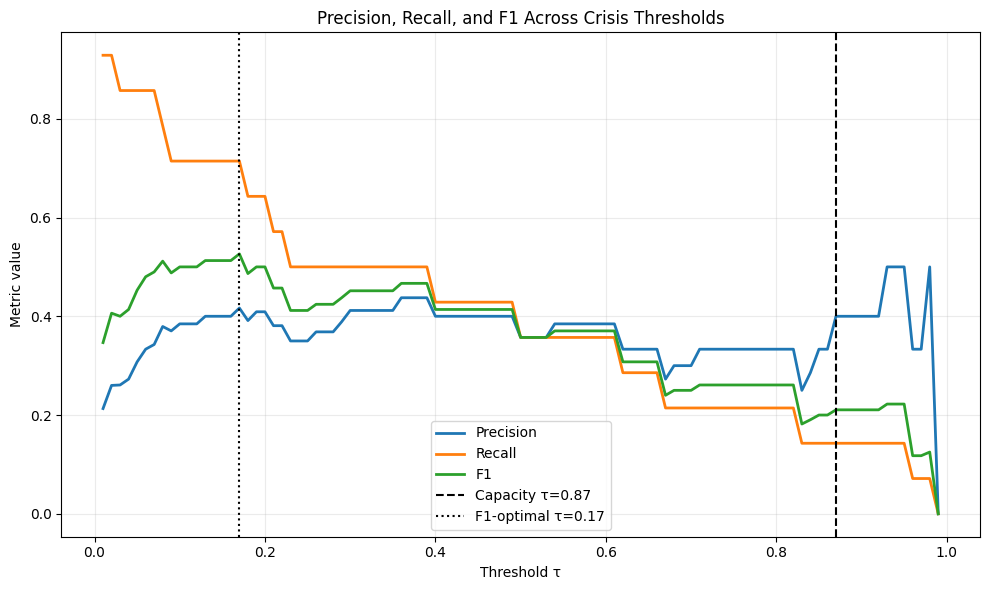


Written memo to the Division Chief:
I recommend the capacity-constrained threshold of τ = 0.87 if the hard operational limit of five missions cannot be exceeded. At this threshold, the model flags 5 countries and achieves crisis recall of 0.143. Operationally, of the 14 crisis countries in the test set, we would catch 2 and miss 12. The tradeoff is that this threshold respects scarce IMF staffing capacity, but it may sacrifice recall compared with a more aggressive threshold that sends more than five missions.


In [12]:
# ============================================================
# STEP 3.4 — Threshold analysis under 5-mission constraint
# ============================================================

thresholds = np.round(np.arange(0.01, 1.00, 0.01), 2)
rows = []
for tau in thresholds:
    preds = (logit_probs_test >= tau).astype(int)
    flagged = int(preds.sum())
    rows.append({
        "threshold": tau,
        "flagged": flagged,
        "precision": precision_score(y_test_crisis, preds, zero_division=0),
        "recall": recall_score(y_test_crisis, preds, zero_division=0),
        "f1": f1_score(y_test_crisis, preds, zero_division=0),
    })

threshold_df = pd.DataFrame(rows)

capacity_options = threshold_df[threshold_df["flagged"] <= 5]
if len(capacity_options) == 0:
    capacity_row = threshold_df.iloc[-1]
else:
    # Lowest threshold among those that do not exceed 5 flagged countries = most aggressive within capacity.
    capacity_row = capacity_options.sort_values("threshold").iloc[0]

f1_row = threshold_df.sort_values(["f1", "recall"], ascending=False).iloc[0]

print("Capacity-constrained threshold:")
print(f"  τ = {capacity_row['threshold']:.2f}")
print(f"  Countries flagged: {int(capacity_row['flagged'])}")
print(f"  Precision: {capacity_row['precision']:.3f}")
print(f"  Recall: {capacity_row['recall']:.3f}")

print("\nF1-optimal threshold:")
print(f"  τ = {f1_row['threshold']:.2f}")
print(f"  Countries flagged: {int(f1_row['flagged'])}")
print(f"  Precision: {f1_row['precision']:.3f}")
print(f"  Recall: {f1_row['recall']:.3f}")
print(f"  F1: {f1_row['f1']:.3f}")

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(threshold_df["threshold"], threshold_df["precision"], label="Precision", linewidth=2)
ax.plot(threshold_df["threshold"], threshold_df["recall"], label="Recall", linewidth=2)
ax.plot(threshold_df["threshold"], threshold_df["f1"], label="F1", linewidth=2)
ax.axvline(capacity_row["threshold"], linestyle="--", color="black", label=f"Capacity τ={capacity_row['threshold']:.2f}")
ax.axvline(f1_row["threshold"], linestyle=":", color="black", label=f"F1-optimal τ={f1_row['threshold']:.2f}")
ax.set_xlabel("Threshold τ")
ax.set_ylabel("Metric value")
ax.set_title("Precision, Recall, and F1 Across Crisis Thresholds")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

total_crises_test = int(y_test_crisis.sum())
capacity_preds = (logit_probs_test >= capacity_row["threshold"]).astype(int)
cap_cm = confusion_matrix(y_test_crisis, capacity_preds, labels=[0, 1])
cap_tn, cap_fp, cap_fn, cap_tp = cap_cm.ravel()

print("\nWritten memo to the Division Chief:")
print(f"I recommend the capacity-constrained threshold of τ = {capacity_row['threshold']:.2f} if the hard operational limit of five missions cannot be exceeded. At this threshold, the model flags {int(capacity_row['flagged'])} countries and achieves crisis recall of {capacity_row['recall']:.3f}. Operationally, of the {total_crises_test} crisis countries in the test set, we would catch {cap_tp} and miss {cap_fn}. The tradeoff is that this threshold respects scarce IMF staffing capacity, but it may sacrifice recall compared with a more aggressive threshold that sends more than five missions.")


# Phase 4: AI Context Engineering — The P.R.I.M.E. Framework

The assignment requires exact P.R.I.M.E. prompts and execution of the AI-generated diagnostics. I include the prompt text first, then the executed Python analysis.


## Task 4.1: Bootstrap Confidence Intervals for the Lasso Path / Lasso Selection Stability

### Exact P.R.I.M.E. prompt submitted

**Prep:** I am working in a Google Colab notebook for an IMF-style sovereign risk assignment. I already have standardized training data named `X_train_scaled`, continuous growth outcome named `y_train_growth`, and predictor names named `feature_names`. I also have imported NumPy, pandas, matplotlib, and `LassoCV` from scikit-learn.

**Request:** Write Python code that draws 200 bootstrap resamples with replacement from the training data. For each bootstrap sample, fit `LassoCV(cv=5, max_iter=100000, random_state=...)` and record whether each predictor has a non-zero coefficient at the selected alpha. Then compute each predictor's selection frequency across the 200 bootstrap samples.

**Iterate:** Make the code robust and readable. Use a fixed random seed for reproducibility, show progress every 25 bootstrap iterations, and store the result in a DataFrame called `stability_df` with columns `Predictor` and `Selection Frequency`.

**Mechanism Check:** After the loop, verify that all selection frequencies are between 0 and 1 and that the DataFrame has one row per predictor.

**Evaluate:** Produce a horizontal bar chart ranking predictors by selection frequency, with a vertical reference line at 0.50. Print the stable predictors selected more than 80% of the time and fragile predictors selected less than 30% of the time.


Completed 25/200 bootstrap resamples
Completed 50/200 bootstrap resamples
Completed 75/200 bootstrap resamples
Completed 100/200 bootstrap resamples
Completed 125/200 bootstrap resamples
Completed 150/200 bootstrap resamples
Completed 175/200 bootstrap resamples
Completed 200/200 bootstrap resamples


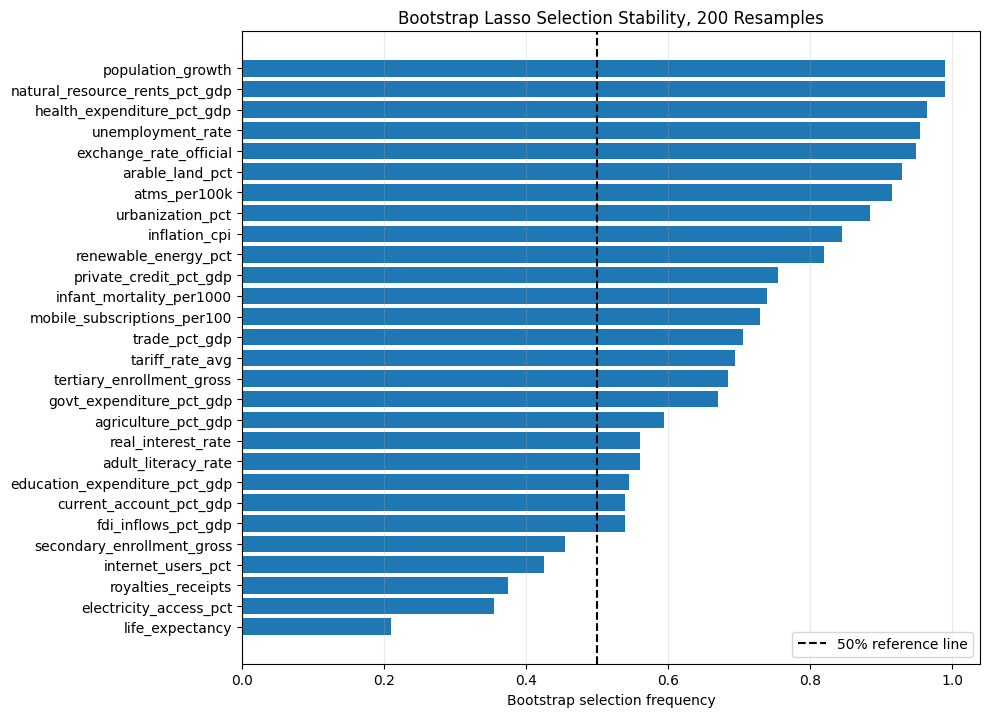

Stable predictors selected >80% of the time:


,Predictor,Selection Frequency
25,population_growth,0.990
15,natural_resource_rents_pct_gdp,0.990
22,health_expenditure_pct_gdp,0.965
23,unemployment_rate,0.955
16,exchange_rate_official,0.950
0,arable_land_pct,0.930
6,atms_per100k,0.915
26,urbanization_pct,0.885
8,inflation_cpi,0.845
5,renewable_energy_pct,0.820


Fragile predictors selected <30% of the time:


,Predictor,Selection Frequency
24,life_expectancy,0.21



Written response:
Stable predictors selected more than 80% of the time are: ['population_growth', 'natural_resource_rents_pct_gdp', 'health_expenditure_pct_gdp', 'unemployment_rate', 'exchange_rate_official', 'arable_land_pct', 'atms_per100k', 'urbanization_pct', 'inflation_cpi', 'renewable_energy_pct']. Fragile predictors selected less than 30% of the time include: ['life_expectancy']. Selection instability means many WDI variables contain overlapping information; when predictors are correlated, Lasso may choose one indicator from a cluster in one bootstrap sample and a different but related indicator in another sample.


In [13]:
# ============================================================
# TASK 4.1 — Bootstrap Lasso selection stability
# ============================================================

n_boot = 200
rng = np.random.default_rng(42)
n_train, n_features = X_train_scaled.shape
selection_matrix = np.zeros((n_boot, n_features), dtype=int)

for b in range(n_boot):
    sample_idx = rng.choice(n_train, size=n_train, replace=True)
    X_b = X_train_scaled[sample_idx]
    y_b = y_train_growth[sample_idx]
    model_b = LassoCV(alphas=lambda_grid, cv=5, max_iter=100_000, random_state=42 + b)
    model_b.fit(X_b, y_b)
    selection_matrix[b, :] = (np.abs(model_b.coef_) > 1e-8).astype(int)
    if (b + 1) % 25 == 0:
        print(f"Completed {b + 1}/{n_boot} bootstrap resamples")

selection_freq = selection_matrix.mean(axis=0)
stability_df = pd.DataFrame({
    "Predictor": feature_names,
    "Selection Frequency": selection_freq
}).sort_values("Selection Frequency", ascending=True)

assert stability_df["Selection Frequency"].between(0, 1).all()
assert len(stability_df) == len(feature_names)

fig, ax = plt.subplots(figsize=(10, max(7, 0.26 * len(stability_df))))
ax.barh(stability_df["Predictor"], stability_df["Selection Frequency"])
ax.axvline(0.50, linestyle="--", color="black", label="50% reference line")
ax.set_xlabel("Bootstrap selection frequency")
ax.set_title("Bootstrap Lasso Selection Stability, 200 Resamples")
ax.legend()
ax.grid(axis="x", alpha=0.25)
plt.tight_layout()
plt.show()

stable_predictors = stability_df[stability_df["Selection Frequency"] > 0.80].sort_values("Selection Frequency", ascending=False)
fragile_predictors = stability_df[stability_df["Selection Frequency"] < 0.30].sort_values("Selection Frequency", ascending=True)

print("Stable predictors selected >80% of the time:")
display(stable_predictors.round(3))
print("Fragile predictors selected <30% of the time:")
display(fragile_predictors.round(3))

stable_names = stable_predictors["Predictor"].tolist()
fragile_names = fragile_predictors["Predictor"].tolist()

print("\nWritten response:")
print(f"Stable predictors selected more than 80% of the time are: {stable_names if stable_names else 'none in this run'}. Fragile predictors selected less than 30% of the time include: {fragile_names[:10] if fragile_names else 'none in this run'}. Selection instability means many WDI variables contain overlapping information; when predictors are correlated, Lasso may choose one indicator from a cluster in one bootstrap sample and a different but related indicator in another sample.")


## Task 4.2: Cost-Sensitive Threshold Optimization

### Exact P.R.I.M.E. prompt submitted

**Prep:** I am working in a Google Colab notebook for an IMF crisis-classification assignment. I already have test-set crisis labels named `y_test_crisis`, logistic-regression predicted crisis probabilities named `logit_probs_test`, and a threshold results table from Phase 3 named `threshold_df`. A missed crisis is a False Negative and costs 50 billion dollars. A false alarm is a False Positive and costs 2 million dollars.

**Request:** Write Python code that sweeps thresholds from 0.01 to 0.99. At each threshold, convert predicted probabilities into class predictions and compute the total expected cost using `FN * 50_000_000_000 + FP * 2_000_000`.

**Iterate:** Store the result in a DataFrame called `cost_df` with threshold, FP, FN, total cost, and total cost in billions. Identify the cost-minimizing threshold.

**Mechanism Check:** Verify that the cost-minimizing threshold is actually the row with the smallest total cost, and print the FP and FN counts at that threshold.

**Evaluate:** Plot the expected cost curve as a function of threshold, annotate the cost-minimizing threshold with a vertical line, and compare it with the F1-optimal threshold and capacity-constrained threshold from Phase 3.


Cost-minimizing threshold:
  τ = 0.02
  FP = 37
  FN = 1
  Total expected cost = $50.074B


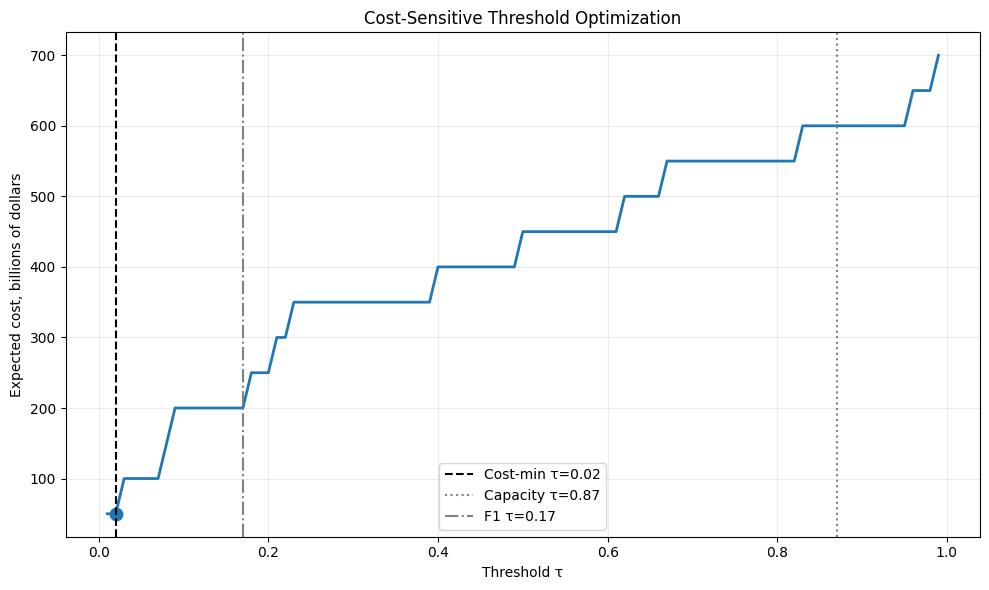


Comparison:
Cost-minimizing τ:       0.02
F1-optimal τ:            0.17
Capacity-constrained τ:  0.87

Written response:
The cost-minimizing threshold is τ = 0.02, compared with the F1-optimal threshold of 0.17 and the capacity-constrained threshold of 0.87. These thresholds differ because F1 balances precision and recall statistically, the capacity rule limits the number of missions, and the cost rule heavily penalizes missed crises. Given the assignment's cost assumptions, I would recommend the cost-minimizing threshold unless the five-mission cap is absolutely binding; if capacity is binding, the IMF should use the capacity-constrained threshold while acknowledging the extra expected cost from missed crises.


In [14]:
# ============================================================
# TASK 4.2 — Cost-sensitive threshold optimization
# ============================================================

FN_COST = 50_000_000_000   # $50B
FP_COST = 2_000_000        # $2M

cost_rows = []
for tau in thresholds:
    preds = (logit_probs_test >= tau).astype(int)
    cm_tau = confusion_matrix(y_test_crisis, preds, labels=[0, 1])
    tn_tau, fp_tau, fn_tau, tp_tau = cm_tau.ravel()
    total_cost = fn_tau * FN_COST + fp_tau * FP_COST
    cost_rows.append({
        "threshold": tau,
        "FP": fp_tau,
        "FN": fn_tau,
        "TP": tp_tau,
        "TN": tn_tau,
        "Total Cost": total_cost,
        "Total Cost ($B)": total_cost / 1_000_000_000,
    })

cost_df = pd.DataFrame(cost_rows)
cost_row = cost_df.loc[cost_df["Total Cost"].idxmin()]
assert cost_row["Total Cost"] == cost_df["Total Cost"].min()

print("Cost-minimizing threshold:")
print(f"  τ = {cost_row['threshold']:.2f}")
print(f"  FP = {int(cost_row['FP'])}")
print(f"  FN = {int(cost_row['FN'])}")
print(f"  Total expected cost = ${cost_row['Total Cost ($B)']:.3f}B")

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(cost_df["threshold"], cost_df["Total Cost ($B)"], linewidth=2)
ax.axvline(cost_row["threshold"], linestyle="--", color="black", label=f"Cost-min τ={cost_row['threshold']:.2f}")
ax.axvline(capacity_row["threshold"], linestyle=":", color="gray", label=f"Capacity τ={capacity_row['threshold']:.2f}")
ax.axvline(f1_row["threshold"], linestyle="-.", color="gray", label=f"F1 τ={f1_row['threshold']:.2f}")
ax.scatter([cost_row["threshold"]], [cost_row["Total Cost ($B)"]], s=80)
ax.set_xlabel("Threshold τ")
ax.set_ylabel("Expected cost, billions of dollars")
ax.set_title("Cost-Sensitive Threshold Optimization")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

print("\nComparison:")
print(f"Cost-minimizing τ:       {cost_row['threshold']:.2f}")
print(f"F1-optimal τ:            {f1_row['threshold']:.2f}")
print(f"Capacity-constrained τ:  {capacity_row['threshold']:.2f}")

print("\nWritten response:")
print(f"The cost-minimizing threshold is τ = {cost_row['threshold']:.2f}, compared with the F1-optimal threshold of {f1_row['threshold']:.2f} and the capacity-constrained threshold of {capacity_row['threshold']:.2f}. These thresholds differ because F1 balances precision and recall statistically, the capacity rule limits the number of missions, and the cost rule heavily penalizes missed crises. Given the assignment's cost assumptions, I would recommend the cost-minimizing threshold unless the five-mission cap is absolutely binding; if capacity is binding, the IMF should use the capacity-constrained threshold while acknowledging the extra expected cost from missed crises.")
